# Benchmark SemIf: MLX source precision versus 4-bit

This is the notebook companion to `benchmark.py`. It runs the same evaluator rather than maintaining a second implementation. Complete the conversion in `01_create_and_benchmark_semif_mlx.ipynb` first. Use the pinned environment in the single README and select its Python kernel. The default cells inspect existing results; enable `RUN_BENCHMARK` to execute a fresh run on Apple Silicon.

The question is whether the saved 4-bit model preserves decision accuracy, and how latency and memory change relative to the **same MLX runtime** at source precision (BF16 plus FP32 components). Historical Torch/MPS scores are not the baseline for this comparison.

## 1. Inspect the evaluation contract

The supplied dataset has 231 public JevBench decisions with fixed IDs, labels, state and question. It is evaluation-only data, not a held-out test: upstream development used public examples. No train split or validation-based tuning is performed here. Source-model training is external to this lesson and contamination is unknown. A separate train/validation/test study is needed for stronger generalization claims.

Keep the entire fixed sample for the final comparison. A small `--samples` run is only a pipeline check. Both models see the same token IDs; gold labels are used only for scoring.

In [1]:
import json
import subprocess
import sys
from collections import Counter
from pathlib import Path

from IPython.display import Image, display

ROOT = Path.cwd().resolve()
assert (ROOT / 'benchmark.py').is_file(), 'Run from 2-best_model_card.'
MODEL = ROOT / 'artifacts/semif-4b-mlx-4bit'
RESULTS = ROOT / 'results/paired'
SOURCE = None  # Optional existing pinned HF snapshot directory.
RUN_BENCHMARK = False
tasks = json.loads((ROOT / 'data/tasks.json').read_text())
assert len(tasks) == 231 and len({task['id'] for task in tasks}) == 231
print('Public decisions:', len(tasks))
print('Question types:', dict(Counter(task['question']['type'] for task in tasks)))
print('Tiers:', dict(Counter(task['tier'] for task in tasks)))


Public decisions: 231
Question types: {'choice': 139, 'noul': 74, 'score': 18}
Tiers: {'easy': 48, 'hard': 111, 'original': 72}


## 2. Run both models in isolated processes

The evaluator first loads the unquantized source, then exits that worker before loading the saved 4-bit export. This avoids keeping both weight sets resident on a 16 GiB Mac. Each worker gets one independent synthetic warmup and then runs batch size one. Inference is synchronized before recording latency.

Set `RUN_BENCHMARK=True` to run the command below. Select a new `RESULTS` directory because existing reports are protected against overwrite. If `SOURCE` is unset, the pinned base is downloaded/reused through Hugging Face's cache. Progress prints at bounded intervals.

In [2]:
command = [sys.executable, str(ROOT / 'benchmark.py'), '--model', str(MODEL),
           '--output', str(RESULTS)]
if SOURCE:
    command.extend(['--source', str(SOURCE)])
print('Command arguments:', command)
if RUN_BENCHMARK:
    subprocess.run(command, cwd=ROOT, check=True)
assert (RESULTS / 'summary.json').is_file(), 'Complete benchmark.py before reading results.'


Command arguments: ['/Users/marco/GitHub/LLM-crash-course/21-openjev/1-quantization/.venv/bin/python', '/Users/marco/GitHub/LLM-crash-course/21-openjev/2-best_model_card/benchmark.py', '--model', '/Users/marco/GitHub/LLM-crash-course/21-openjev/2-best_model_card/artifacts/semif-4b-mlx-4bit', '--output', '/Users/marco/GitHub/LLM-crash-course/21-openjev/2-best_model_card/results/paired']


## 3. Check the pairing before interpreting accuracy

Same example IDs are necessary but not sufficient: preprocessing or tokenization differences can invalidate a quantization comparison. Compare prompt and token hashes as well. Exact-match accuracy selects the largest option probability and compares its label with the reference. Score questions are classified by their most probable ordinal level.

In [3]:
baseline = json.loads((RESULTS / 'baseline.json').read_text())
quantized = json.loads((RESULTS / 'quantized.json').read_text())
summary = json.loads((RESULTS / 'summary.json').read_text())
protocol = json.loads((RESULTS / 'protocol.json').read_text())
for before, after in zip(baseline['results'], quantized['results'], strict=True):
    for key in ('id', 'expected', 'prompt_sha256', 'token_ids_sha256'):
        assert before[key] == after[key], (before['id'], key)
assert len(baseline['results']) == protocol['n']
print('Matched examples and token streams:', protocol['n'])
print('Baseline parameter dtypes:', baseline['parameter_dtypes'])
for row in summary['measured']:
    print(f"{row['variant']}: {row['correct']}/{row['total']} correct, "
          f"{row['accuracy_percent']:.2f}% accuracy; median {row['median_latency_ms']:.1f} ms; "
          f"peak MLX {row['peak_mlx_gib']:.3f} GiB")


Matched examples and token streams: 231
Baseline parameter dtypes: ['mlx.core.bfloat16', 'mlx.core.float32']
baseline: 186/231 correct, 80.52% accuracy; median 694.1 ms; peak MLX 8.997 GiB
quantized: 180/231 correct, 77.92% accuracy; median 566.1 ms; peak MLX 3.370 GiB


## 4. Compare quality and resources together

A smaller checkpoint can be faster while losing accuracy. Keep the quality panel beside the resource panels. Median latency includes prompt construction, tokenization and synchronized inference, but excludes model loading and warmup. Peak MLX includes live parameters. Process RSS is a separate post-run snapshot; overlapping unified-memory counters must not be added. Other machine workloads were not explicitly stopped.

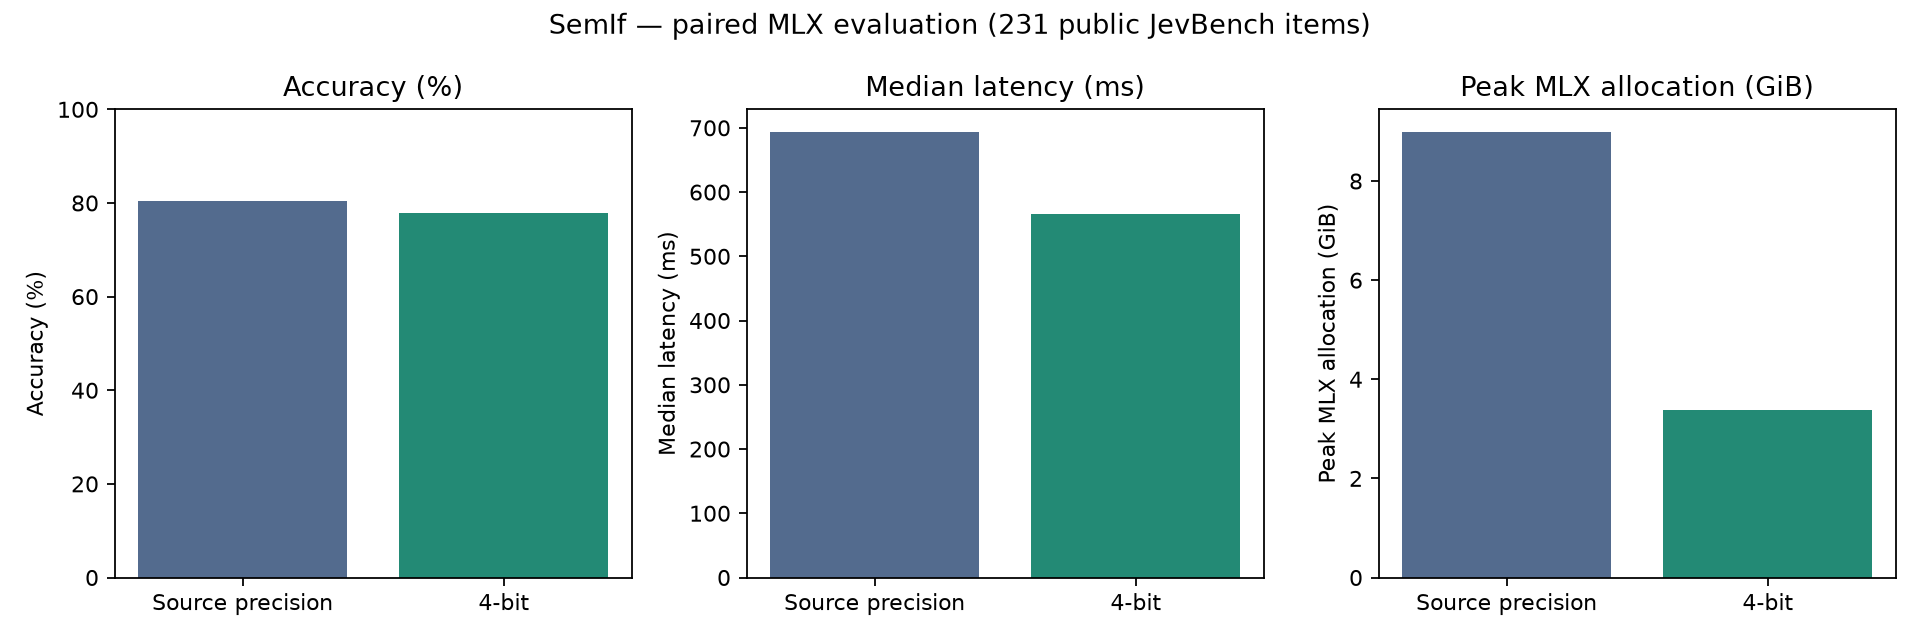

Quantized minus baseline (percentage points): -2.5974025974025974
Paired bootstrap 95% interval: [-6.926406926406926, 1.7316017316017316]
Regressions: 15
Improvements: 9


In [4]:
display(Image(filename=str(RESULTS / 'comparison.png')))
paired = summary['paired']
print('Quantized minus baseline (percentage points):', paired['quantized_minus_baseline_pp'])
print('Paired bootstrap 95% interval:', paired['paired_bootstrap_95_pp'])
print('Regressions:', len(paired['regressions']))
print('Improvements:', len(paired['improvements']))


## 5. Inspect regressions and improvements

A regression changes a previously correct answer to an incorrect one; an improvement does the reverse. The JSON files retain all cases. Below we display the first three IDs in each category in the original fixed order, without choosing examples for a favorable narrative. The paired bootstrap uses 10,000 resamples with seed 42. Related public items are treated as independent, so its interval is descriptive. A tie or an interval crossing zero is not proof of general equivalence.

In [5]:
before_by_id = {row['id']: row for row in baseline['results']}
after_by_id = {row['id']: row for row in quantized['results']}
for category in ('regressions', 'improvements'):
    print(category, paired[category])
    for task_id in paired[category][:3]:
        before, after = before_by_id[task_id], after_by_id[task_id]
        print({'id': task_id, 'expected': before['expected'],
               'baseline': before['predicted'], 'quantized': after['predicted'],
               'baseline_probabilities': before['probabilities'],
               'quantized_probabilities': after['probabilities']})


regressions ['hard-sol-a-multi_hop-07', 'hard-opus-a-long_policy-08', 'hard-opus-a-long_policy-11', 'hard-opus-b-ambiguous-02', 'original-adequacy-03-1', 'hard-sol-b-long_policy-06', 'hard-opus-b-tradeoff-12', 'hard-opus-b-tradeoff-08', 'hard-opus-b-probability-01', 'original-policy-03-1', 'hard-opus-b-ambiguous-09', 'original-adequacy-03-0', 'hard-opus-b-tradeoff-01', 'hard-opus-a-temporal_numeric-03', 'hard-sol-a-multi_hop-08']
{'id': 'hard-sol-a-multi_hop-07', 'expected': 'admit', 'baseline': 'admit', 'quantized': 'deny_prerequisite', 'baseline_probabilities': {'admit': 0.5970581376278262, 'deny_prerequisite': 0.3195821916555581, 'deny_score': 0.06292946472432376, 'manual_equivalency': 0.020430205992291936}, 'quantized_probabilities': {'admit': 0.4156385866698231, 'deny_prerequisite': 0.4709802215197921, 'deny_score': 0.049640950132161174, 'manual_equivalency': 0.06374024167822365}}
{'id': 'hard-opus-a-long_policy-08', 'expected': 'parts_covered_labour_charged', 'baseline': 'parts_c

## 6. Measure tokens per second

Jev decisions do not generate text. Their input-token throughput includes prompt construction, tokenization and synchronized inference. To measure the usual LLM generation rate, `benchmark_tokens.py` runs three separate fixed chat prompts, greedily generating up to 128 tokens each with thinking disabled. Both variants receive identical prompt token IDs, run in separate processes and get an independent warmup.

The generation benchmark reports MLX-LM's prompt and generation timing separately. Rates are aggregated as total tokens divided by total measured time, not the arithmetic mean of rates. Model loading, chat formatting and warmup are excluded. These short-prompt rates need not match Jev's much longer inputs. Generated text and exact token counts are preserved; this is a speed test, not an additional quality benchmark.

baseline: prompt 85.78 tok/s; generation 11.44 tok/s
quantized: prompt 198.70 tok/s; generation 35.64 tok/s
Jev baseline: 382.50 input tok/s; 0.548 decisions/s
Jev quantized: 384.80 input tok/s; 0.551 decisions/s


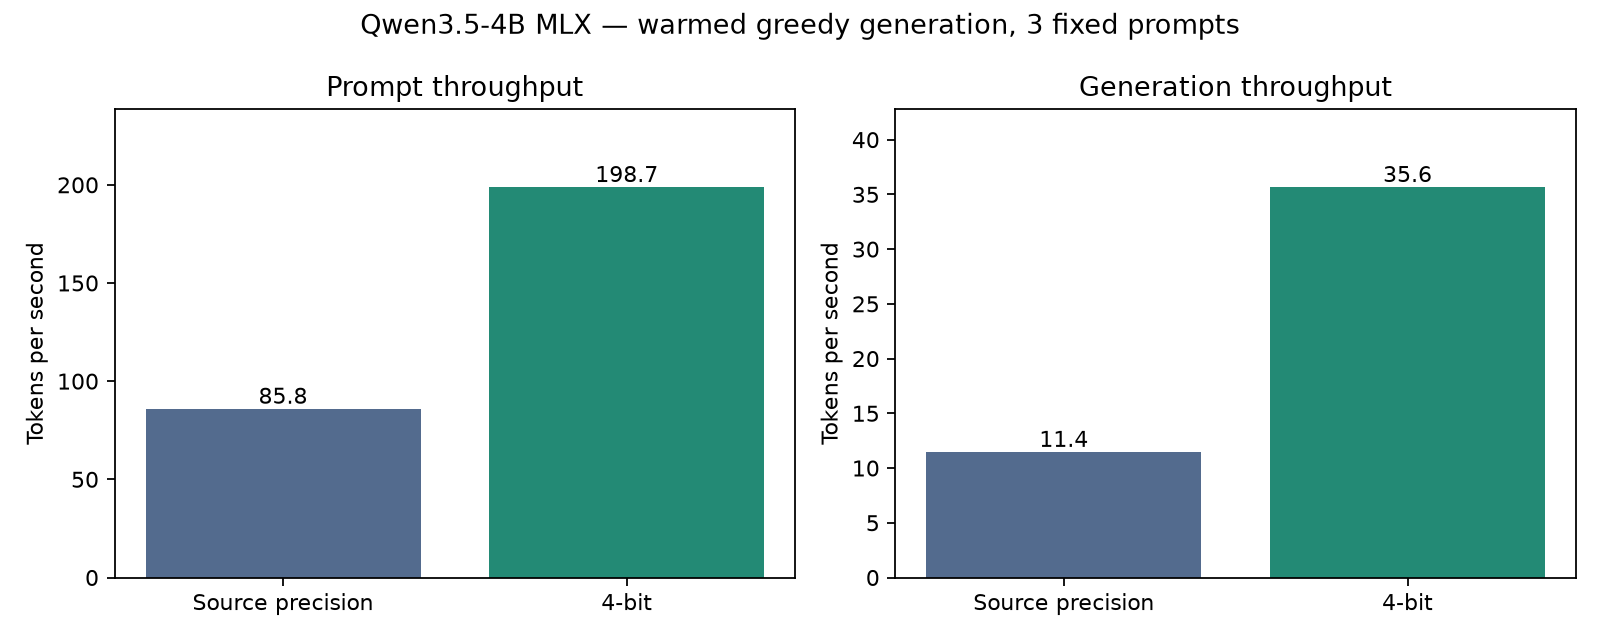

In [6]:
TOKEN_RESULTS = ROOT / 'results/tokens'
RUN_TOKEN_BENCHMARK = False
if RUN_TOKEN_BENCHMARK:
    token_command = [sys.executable, str(ROOT / 'benchmark_tokens.py'),
                     '--model', str(MODEL), '--output', str(TOKEN_RESULTS)]
    if SOURCE:
        token_command.extend(['--source', str(SOURCE)])
    subprocess.run(token_command, cwd=ROOT, check=True)
token_summary = json.loads((TOKEN_RESULTS / 'summary.json').read_text())
for row in token_summary:
    print(f"{row['variant']}: prompt {row['prompt_tokens_per_second']:.2f} tok/s; "
          f"generation {row['generation_tokens_per_second']:.2f} tok/s")
for row in summary['measured']:
    print(f"Jev {row['variant']}: {row['input_tokens_per_second']:.2f} input tok/s; "
          f"{row['decisions_per_second']:.3f} decisions/s")
display(Image(filename=str(TOKEN_RESULTS / 'tokens_per_second.png')))


## 7. Report the result honestly

Quote correct/total, both accuracies, their paired difference and uncertainty, the number of changed outcomes, hardware and runtime. Preserve the chart and per-example predictions. Identify this as public JevBench evaluation, not an unseen test or a private leaderboard reproduction.

These results concern SemIf's MLX export. They neither rank it against an unevaluated reflex quantized checkpoint nor validate an Ollama/GGUF artifact. An independent held-out quality study and an Ollama implementation remain separate work.